# M10 — EDA: English popularity vs. Czech bestseller status

**Question (from supervisor):** Are bestsellers on the English market (books with many Goodreads ratings) automatically bestsellers in Czech, and vice versa — are there Czech bestsellers that were *not* popular in their original language?

**Why this matters for the thesis:** If foreign popularity strongly predicts Czech bestseller status, our model is redundant — a publisher could just sort foreign books by ratings count and pick the top. If the relationship is weak, it justifies the need for a multivariate model that combines popularity with genre, language, and timing signals.

**v2 (2026-05-23) — work-aggregated popularity:** Previously this notebook used the edition-level `gr_ratings_count` from `training_dataset.csv`. That under-counted total popularity for books where our matcher picked a minor edition. This version sums ratings across *all* Goodreads editions of the same `gr_work_id`, which matches what a publisher sees on a Goodreads work page.

Note: `work_ratings_count` here is the *total* count from the 2017 Goodreads snapshot, aggregated at work level. It's allowed as an EDA variable but NOT as a model feature (excluded from `X_train.csv` per project instruction about temporal leakage — the model uses `pre_cutoff_ratings_count` from the reviews dump instead).

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 200)

REPO    = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
INTERIM = REPO / "data" / "interim"
FIGS    = REPO / "reports" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

train = pd.read_csv(INTERIM / "training_dataset.csv", dtype=str, keep_default_na=False)

train["gr_ratings_count"]  = pd.to_numeric(train["gr_ratings_count"],  errors="coerce").fillna(0).astype(int)
train["sckn_appearances"]  = pd.to_numeric(train["sckn_appearances"],  errors="coerce").fillna(0).astype(int)
train["sckn_best_rank"]    = pd.to_numeric(train["sckn_best_rank"],    errors="coerce")
train["is_positive"]       = (train["sckn_appearances"] >= 1).astype(int)

print(f"Training cohort: {len(train):,} rows")
print(f"  SCKN positives: {train['is_positive'].sum():,} ({train['is_positive'].mean():.1%})")

Training cohort: 24,161 rows
  SCKN positives: 1,287 (5.3%)


## 0 — Compute work-aggregated ratings count

Load `goodreads_book_details.json` (book_id → [norm_title, ratings_count, pub_year, language_code, work_id]) and `goodreads_work_to_books.json`, then for each training row sum ratings across all editions of its work.

We use this `work_ratings_count` for everything below — that's the metric the supervisor's question is naturally about (and the one a publisher actually sees).

In [2]:
import time
t0 = time.time()

print("Loading book_details.json …", flush=True)
with open(INTERIM / "goodreads_book_details.json", encoding="utf-8") as f:
    book_details = json.load(f)
print(f"  {len(book_details):,} books  ({time.time()-t0:.1f}s)")

print("Loading work_to_books.json …", flush=True)
with open(INTERIM / "goodreads_work_to_books.json", encoding="utf-8") as f:
    work_to_books = json.load(f)
print(f"  {len(work_to_books):,} works  ({time.time()-t0:.1f}s)")

# Sum ratings across editions per work
print("Computing work-aggregated ratings counts …", flush=True)
work_ratings: dict[str, int] = {}
for wid, bids in work_to_books.items():
    total = 0
    for bid in bids:
        d = book_details.get(bid)
        if d:
            total += int(d[1] or 0)   # d = [norm_title, ratings_count, ...]
    work_ratings[wid] = total
print(f"  {len(work_ratings):,} works aggregated  ({time.time()-t0:.1f}s)")

# Project onto training rows. Rows without a gr_work_id fall back to their
# edition-level gr_ratings_count.
def lookup_work_ratings(row):
    wid = row.get("gr_work_id", "").strip()
    if wid and wid in work_ratings:
        return work_ratings[wid]
    return row["gr_ratings_count"]

train["work_ratings_count"] = train.apply(lookup_work_ratings, axis=1).astype(int)

print()
print("Edition-level vs work-aggregated ratings count:")
print("  edition (median / max):",
      int(train['gr_ratings_count'].median()), "/", train['gr_ratings_count'].max())
print("  work    (median / max):",
      int(train['work_ratings_count'].median()), "/", train['work_ratings_count'].max())
ratio = train['work_ratings_count'].sum() / max(train['gr_ratings_count'].sum(), 1)
print(f"  total ratio (sum work / sum edition): {ratio:.2f}x")

Loading book_details.json …


  2,360,655 books  (16.3s)
Loading work_to_books.json …


  1,521,962 works  (21.5s)
Computing work-aggregated ratings counts …


  1,521,962 works aggregated  (24.3s)



Edition-level vs work-aggregated ratings count:
  edition (median / max): 172 / 1962813
  work    (median / max): 951 / 5064668
  total ratio (sum work / sum edition): 4.58x


## 1 — Correlation: English popularity ↔ Czech bestseller status

Both Pearson (linear) and Spearman (rank-based). Spearman is the honest number for heavy-tailed counts.

In [3]:
pearson  = train[["work_ratings_count", "sckn_appearances", "is_positive"]].corr(method="pearson")
spearman = train[["work_ratings_count", "sckn_appearances", "is_positive"]].corr(method="spearman")

print("Pearson correlations (linear):")
print(pearson.round(4).to_string())
print()
print("Spearman correlations (rank — more appropriate for heavy-tailed counts):")
print(spearman.round(4).to_string())

Pearson correlations (linear):
                    work_ratings_count  sckn_appearances  is_positive
work_ratings_count              1.0000            0.2656       0.1761
sckn_appearances                0.2656            1.0000       0.3905
is_positive                     0.1761            0.3905       1.0000

Spearman correlations (rank — more appropriate for heavy-tailed counts):
                    work_ratings_count  sckn_appearances  is_positive
work_ratings_count              1.0000            0.1508       0.1494
sckn_appearances                0.1508            1.0000       0.9995
is_positive                     0.1494            0.9995       1.0000


## 2 — Top-N analysis: does English popularity predict Czech success?

Sort training set by `work_ratings_count` descending. For each top-N bucket, compute the fraction that are SCKN positive. Baseline ≈ 5.4%.

In [4]:
sorted_by_gr = train.sort_values("work_ratings_count", ascending=False).reset_index(drop=True)
baseline = train["is_positive"].mean()

results = []
for n in [50, 100, 250, 500, 1000, 2500, 5000, 10000, len(train)]:
    top_n = sorted_by_gr.head(n)
    pos_count = top_n["is_positive"].sum()
    pos_rate = top_n["is_positive"].mean()
    lift = pos_rate / baseline
    results.append({
        "top_N":              n,
        "min_work_ratings":   int(top_n["work_ratings_count"].min()),
        "n_SCKN_positive":    int(pos_count),
        "pct_positive":       f"{pos_rate:.1%}",
        "lift_vs_baseline":   f"{lift:.2f}x",
    })

topN_table = pd.DataFrame(results)
print(f"Baseline positive rate (all training): {baseline:.1%}")
print()
print(topN_table.to_string(index=False))

Baseline positive rate (all training): 5.3%

 top_N  min_work_ratings  n_SCKN_positive pct_positive lift_vs_baseline
    50            668468               33        66.0%           12.39x
   100            468405               52        52.0%            9.76x
   250            213335               89        35.6%            6.68x
   500            116478              140        28.0%            5.26x
  1000             60313              218        21.8%            4.09x
  2500             21962              380        15.2%            2.85x
  5000              7753              591        11.8%            2.22x
 10000              1710              858         8.6%            1.61x
 24161                10             1287         5.3%            1.00x


## 3 — Reverse view: where do SCKN positives sit on the Goodreads popularity scale?

Among the SCKN positives, distribution of `work_ratings_count` and bucket breakdown.

In [5]:
positives = train[train["is_positive"] == 1].copy()
print(f"SCKN positives: {len(positives):,}")
print()
print("work_ratings_count distribution among SCKN positives:")
print(positives["work_ratings_count"].describe(percentiles=[.1, .25, .5, .75, .9, .95]).round(0).to_string())

SCKN positives: 1,287

work_ratings_count distribution among SCKN positives:
count       1287.0
mean       77039.0
std       297641.0
min           10.0
10%          167.0
25%          840.0
50%         6136.0
75%        30707.0
90%       125787.0
95%       348667.0
max      5064668.0


In [6]:
buckets = [
    (0,     100,     "obscure (<100 ratings)"),
    (100,   1000,    "niche (100–999)"),
    (1000,  10000,   "recognized (1k–10k)"),
    (10000, 100000,  "popular (10k–100k)"),
    (100000, 10**8,  "viral (100k+)"),
]

print("SCKN positives by Goodreads popularity bucket (work-aggregated):")
for lo, hi, label in buckets:
    mask = (positives["work_ratings_count"] >= lo) & (positives["work_ratings_count"] < hi)
    n = mask.sum()
    pct = n / len(positives) * 100
    bar = "█" * int(pct / 2)
    print(f"  {label:<28} : {n:>4} ({pct:>5.1f}%)  {bar}")

SCKN positives by Goodreads popularity bucket (work-aggregated):
  obscure (<100 ratings)       :   90 (  7.0%)  ███
  niche (100–999)              :  252 ( 19.6%)  █████████
  recognized (1k–10k)          :  397 ( 30.8%)  ███████████████
  popular (10k–100k)           :  393 ( 30.5%)  ███████████████
  viral (100k+)                :  155 ( 12.0%)  ██████


## 4 — Concrete examples

### 4a — English bestsellers that flopped in Czech

In [7]:
english_hits_czech_flops = (
    train[train["is_positive"] == 0]
    .sort_values("work_ratings_count", ascending=False)
    .head(20)
    [["author", "original_title", "czech_title", "czech_pub_year",
      "source_lang", "work_ratings_count", "sckn_appearances"]]
)
print("TOP 20 high-Goodreads-popularity books (work-aggregated) that were NEVER in SCKN top 10:")
english_hits_czech_flops

TOP 20 high-Goodreads-popularity books (work-aggregated) that were NEVER in SCKN top 10:


,author,original_title,czech_title,czech_pub_year,source_lang,work_ratings_count,sckn_appearances
12929,"Collins, Suzanne",Catching fire,Hunger games,2013,eng,2013187,0
21100,"Collins, Suzanne",Mockingjay,Hunger games,2019,eng,1895651,0
431,"Sebold, Alice",Lovely bones,Pevné pouto,2003,eng,1684392,0
3132,"Brown, Dan",Da Vinci code travel journal,Da Vinciho kód,2006,eng,1571996,0
6687,"Riordan, Rick",Lightning thief,Percy Jackson,2009,eng,1457494,0
1498,"Niffenegger, Audrey",Time traveler's wife,Žena cestovatele časem,2004,eng,1328427,0
22873,"Paolini, Christopher",Eragon,Odkaz Dračích jezdců,2022,eng,1148651,0
23799,"Gruen, Sara",Water for elephants,Voda pro slony,2024,eng,1123701,0
19511,"Pullman, Philip",Nothern lights,Jeho temné esence,2018,eng,1013796,0
11170,"Chbosky, Stephen",Perks of being a wallflower,"Ten, kdo stojí v koutě",2012,eng,973572,0


### 4b — Czech bestsellers with low Goodreads popularity (work-aggregated)

After work-aggregation, this list should contain *fewer* artifacts (non-English originals where we'd matched to a minor edition). Books that remain here are real "low-Goodreads-exposure but Czech bestseller" cases.

In [8]:
czech_hits_low_english = (
    positives
    .sort_values("work_ratings_count", ascending=True)
    .head(20)
    [["author", "original_title", "czech_title", "czech_pub_year",
      "source_lang", "work_ratings_count", "sckn_appearances", "sckn_best_rank"]]
)
print("TOP 20 SCKN-positive books with the LOWEST work-aggregated Goodreads ratings count:")
czech_hits_low_english

TOP 20 SCKN-positive books with the LOWEST work-aggregated Goodreads ratings count:


,author,original_title,czech_title,czech_pub_year,source_lang,work_ratings_count,sckn_appearances,sckn_best_rank
16265,Áslaug Jónsdóttir,Nei! sagði litla skrímslið,Ne! řeklo strašidýlko,2016,ice,10,1,7.0
16427,"Bass, Guy",Beast of Grubbers Nubbin,Záplaťák,2016,eng,10,1,2.0
21396,"Garnier, Stéphane",Agir et penser comme un chat,Chovejte se jako kočka,2018,fre,10,16,2.0
14936,"Peschke, M",Summer camp queen,Káťa Líbezná,2015,eng,12,1,9.0
139,"Bittleston, Jennie",Secrets of yoga,Tajemství jógy,2003,eng,12,1,10.0
20932,"Martin, George R. R",Fire and blood,Oheň a krev,2019,eng,12,4,2.0
3131,"Fulghum, Robert",Third wish granted,Třetí přání 3,2006,eng,14,3,2.0
17383,"Kaiblinger, Sonja",Totgesagte leben länger,Smrťák Harry,2017,ger,14,1,5.0
1689,"Fulghum, Robert",Third wish,Třetí přání,2004,eng,14,18,1.0
2572,"Fulghum, Robert","Third wish II, the rest of the story, almost",Třetí přání 2,2005,eng,14,9,1.0


### 4c — Both ends together (the "obvious matches")

In [9]:
obvious = (
    positives
    .sort_values("work_ratings_count", ascending=False)
    .head(20)
    [["author", "original_title", "czech_title", "czech_pub_year",
      "source_lang", "work_ratings_count", "sckn_appearances", "sckn_best_rank"]]
)
print("TOP 20 SCKN-positive books with the HIGHEST work-aggregated Goodreads ratings:")
obvious

TOP 20 SCKN-positive books with the HIGHEST work-aggregated Goodreads ratings:


,author,original_title,czech_title,czech_pub_year,source_lang,work_ratings_count,sckn_appearances,sckn_best_rank
7869,"Collins, Suzanne",Hunger games,Hunger games,2010,eng,5064668,5,2.0
2649,"Meyer, Stephenie",Twilight,Stmívání,2008,eng,3991256,57,1.0
11190,"Green, John",Fault in our stars,Hvězdy nám nepřály,2014,eng,2563830,16,3.0
10635,"Roth, Veronica",Divergent,Divergence,2012,eng,2277480,14,2.0
261,"Brown, Dan",Angels & demons,Andělé a démoni,2003,eng,2123290,42,3.0
8520,"Collins, Suzanne",Hungers games. Catching fire,Hunger games,2010,eng,2013187,5,3.0
4642,"Hosseini, Khaled",Kite runner,Lovec draků,2007,eng,1915179,3,4.0
9165,"Collins, Suzanne",Hunger games mockingjay,Hunger games,2011,eng,1895651,4,3.0
5065,"Rowling, J. K",Harry Potter and the Deathly Hallows,Harry Potter a relikvie smrti,2008,eng,1886739,49,1.0
1084,"Rowling, J. K",Harry Potter and the Order of the Phoenix,Harry Potter a Fénixův řád,2004,eng,1873246,92,1.0


## 5 — Conditional probability tables

P(SCKN+ | work_ratings ≥ T) at various thresholds.

In [10]:
thresholds = [100, 500, 1000, 5000, 10000, 50000, 100000, 500000, 1_000_000]

rows = []
for T in thresholds:
    mask = train["work_ratings_count"] >= T
    n_total = mask.sum()
    n_pos   = train.loc[mask, "is_positive"].sum()
    p_cond  = n_pos / n_total if n_total > 0 else 0
    lift    = p_cond / baseline if baseline > 0 else 0
    rows.append({
        "work_ratings ≥":   f"{T:>9,}",
        "n_books_in_pool":  n_total,
        "n_SCKN_positive":  int(n_pos),
        "P(SCKN+ | pool)":  f"{p_cond:.1%}",
        "lift_vs_baseline": f"{lift:.2f}x",
    })

print(f"Baseline P(SCKN+) on whole training: {baseline:.1%}")
print()
print(pd.DataFrame(rows).to_string(index=False))

Baseline P(SCKN+) on whole training: 5.3%

work_ratings ≥  n_books_in_pool  n_SCKN_positive P(SCKN+ | pool) lift_vs_baseline
           100            19586             1197            6.1%            1.15x
           500            14349             1028            7.2%            1.34x
         1,000            11909              945            7.9%            1.49x
         5,000             6375              682           10.7%            2.01x
        10,000             4308              548           12.7%            2.39x
        50,000             1206              246           20.4%            3.83x
       100,000              591              155           26.2%            4.92x
       500,000               90               48           53.3%           10.01x
     1,000,000               34               25           73.5%           13.80x


## 6 — Figure: popularity quartiles vs Czech bestseller rate

Folded in from the retired `07_eda_bestseller_correlation` notebook, now using the
**work-aggregated** `work_ratings_count` (not the edition-level count 07 used).
Bins the cohort into Goodreads-popularity quartiles and plots the SCKN bestseller
rate per quartile. Saves `reports/figures/eda_popularity_quartiles.png`.

Czech bestseller rate by work-aggregated Goodreads popularity quartile:
                       n  bestsellers  gr_min   gr_max  bestseller_rate
work_ratings_q                                                         
Q1 (least popular)  6049          128      10      162         0.021161
Q2                  6032          208     163      951         0.034483
Q3                  6041          287     952     5543         0.047509
Q4 (most popular)   6039          664    5545  5064668         0.109952

Monotonically increasing: True


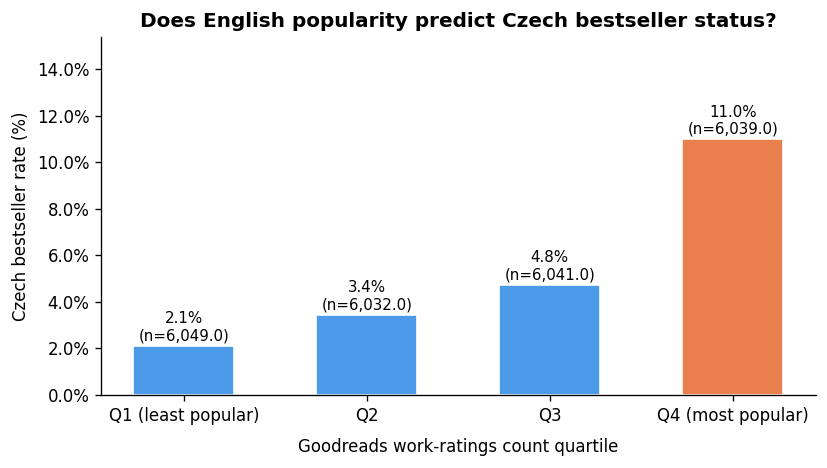

Saved → reports/figures/eda_popularity_quartiles.png


In [11]:
df_q = train.copy()
df_q["work_ratings_q"] = pd.qcut(
    df_q["work_ratings_count"],
    q=4,
    labels=["Q1 (least popular)", "Q2", "Q3", "Q4 (most popular)"],
)

q_stats = (
    df_q.groupby("work_ratings_q", observed=True)
    .agg(
        n=("is_positive", "count"),
        bestsellers=("is_positive", "sum"),
        gr_min=("work_ratings_count", "min"),
        gr_max=("work_ratings_count", "max"),
    )
    .assign(bestseller_rate=lambda x: x["bestsellers"] / x["n"])
)

print("Czech bestseller rate by work-aggregated Goodreads popularity quartile:")
print(q_stats.to_string())

rates = q_stats["bestseller_rate"].values
monotone = all(rates[i] <= rates[i + 1] for i in range(len(rates) - 1))
print(f"\nMonotonically increasing: {monotone}")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    q_stats.index,
    q_stats["bestseller_rate"] * 100,
    color=["#4c9be8", "#4c9be8", "#4c9be8", "#e87f4c"],
    width=0.55,
    edgecolor="white",
)
for bar, (_, row) in zip(bars, q_stats.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{row['bestseller_rate']:.1%}\n(n={row['n']:,})",
        ha="center", va="bottom", fontsize=9,
    )
ax.set_xlabel("Goodreads work-ratings count quartile", labelpad=8)
ax.set_ylabel("Czech bestseller rate (%)")
ax.set_title("Does English popularity predict Czech bestseller status?", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylim(0, max(q_stats["bestseller_rate"]) * 140)
fig.tight_layout()
fig.savefig(FIGS / "eda_popularity_quartiles.png", bbox_inches="tight")
plt.show()
print("Saved → reports/figures/eda_popularity_quartiles.png")


## 7 — Figure: Czech bestseller rate by source language

Also folded in from `07_eda_bestseller_correlation`. Bestseller rate per source
language (min 100 books). Saves `reports/figures/eda_bestseller_rate_by_language.png`.

Czech bestseller rate by source language (min 100 books):
                 n  bestsellers rate_pct
source_lang                             
fin            114            3    2.63%
slo            103            3    2.91%
dut            100            3    3.00%
ger            811           35    4.32%
spa            280           13    4.64%
eng          20633         1054    5.11%
swe            382           29    7.59%
ita            198           16    8.08%
fre            829           68    8.20%
pol            146           12    8.22%
nor            161           24   14.91%


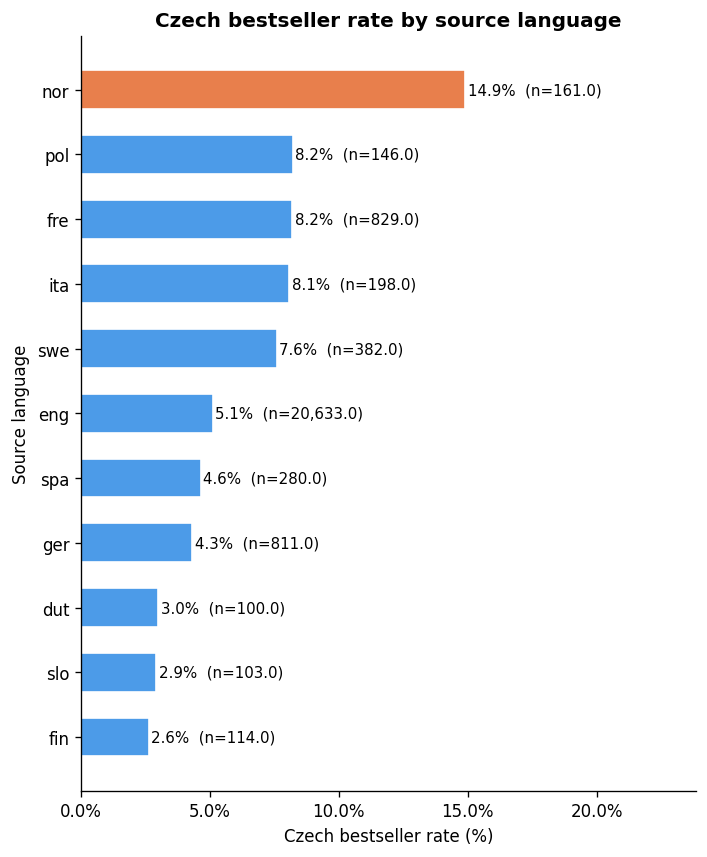

Saved → reports/figures/eda_bestseller_rate_by_language.png


In [12]:
lang_stats = (
    train.groupby("source_lang")
    .agg(n=("is_positive", "count"), bestsellers=("is_positive", "sum"))
    .query("n >= 100")
    .assign(bestseller_rate=lambda x: x["bestsellers"] / x["n"])
    .sort_values("bestseller_rate", ascending=True)
)

print("Czech bestseller rate by source language (min 100 books):")
print(lang_stats.assign(
    rate_pct=lang_stats["bestseller_rate"].map("{:.2%}".format)
)[["n", "bestsellers", "rate_pct"]].to_string())

fig, ax = plt.subplots(figsize=(6, 0.55 * len(lang_stats) + 1.2))
colors = ["#e87f4c" if r == lang_stats["bestseller_rate"].max() else "#4c9be8"
          for r in lang_stats["bestseller_rate"]]
bars = ax.barh(
    lang_stats.index,
    lang_stats["bestseller_rate"] * 100,
    color=colors, edgecolor="white", height=0.6,
)
for bar, (lang, row) in zip(bars, lang_stats.iterrows()):
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{row['bestseller_rate']:.1%}  (n={row['n']:,})",
        va="center", fontsize=9,
    )
ax.set_xlabel("Czech bestseller rate (%)")
ax.set_ylabel("Source language")
ax.set_title("Czech bestseller rate by source language", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlim(0, lang_stats["bestseller_rate"].max() * 160)
fig.tight_layout()
fig.savefig(FIGS / "eda_bestseller_rate_by_language.png", bbox_inches="tight")
plt.show()
print("Saved → reports/figures/eda_bestseller_rate_by_language.png")


## 8 — Summary for thesis discussion (work-aggregated)

Fill in from above:

1. **Correlation work_ratings_count ↔ sckn_appearances (Spearman):** ___
2. **Top-100 by work_ratings_count → % SCKN positive:** ___%  (lift ___x)
3. **% of SCKN positives that are "obscure" (< 1000 work ratings):** ___%
4. **Concrete example, English bestseller that flopped in Czech:** ___
5. **Concrete example, Czech bestseller with low Goodreads count:** ___

**Pattern check:** if (2) is < 50% and (3) is meaningfully positive (> 5%), the data still supports the thesis framing — English popularity alone is a weak filter, multivariate model justified.

These numbers go into:
- Reply to supervisor (Section: EDA support for the framing).
- Thesis Chapter on data analysis.
- Thesis Discussion (justifying why we need a multivariate model).